# StealTheDealAI: Data Exploration (local)

Runs entirely on this machine against `data/raw/*.csv` - no Kaggle needed for this step.

**Before running:** download the two Kaggle datasets and place them in `data/raw/`:
- PromptCloud "Amazon India Products" (~30k rows) → `data/raw/amazon_india_30k.csv`
- Lokesh Parab "Amazon Products Dataset 2020" → `data/raw/Amazon-Products.csv` (the dataset also
  ships ~140 separate per-category CSVs, e.g. `Watches.csv` - `Amazon-Products.csv` is already their
  exact merge, so you can delete the individual category files and keep only this one)

(If your downloaded filenames differ, either rename them or update `RAW_TRAINING_PATH` / `RAW_RAG_PATH` below.)

The last cell prints **recommended values** for `MIN_PRICE`, `MAX_PRICE`, `MAX_RAG_ITEMS`, `DEAL_THRESHOLD_PERCENT`, and `DEAL_THRESHOLD_ABSOLUTE` based on what this notebook finds in your actual data - copy them into `config/settings.py`, then run the `scripts/` pipeline.

In [1]:
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make config.settings importable from the notebook (same values the scripts/ use)
sys.path.insert(0, str(Path.cwd().parent))
from config import settings

# Validated palette (see dataviz skill references/palette.md) - sequential blue for
# magnitude, the categorical order for the top-N category breakdown below.
BLUE, ORANGE, AQUA, YELLOW, MAGENTA, GREEN, VIOLET = (
    "#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7",
)
MUTED = "#898781"
CATEGORICAL = [BLUE, ORANGE, AQUA, YELLOW, MAGENTA, GREEN, VIOLET]

RAW_TRAINING_PATH = settings.DATA_RAW_DIR / "amazon_india_30k.csv"
RAW_RAG_PATH = settings.DATA_RAW_DIR / "Amazon-Products.csv"

print("Current config/settings.py values:")
print(f"  MIN_PRICE={settings.MIN_PRICE}  MAX_PRICE={settings.MAX_PRICE}")
print(f"  MAX_RAG_ITEMS={settings.MAX_RAG_ITEMS}")
print(f"  DEAL_THRESHOLD_PERCENT={settings.DEAL_THRESHOLD_PERCENT}  DEAL_THRESHOLD_ABSOLUTE={settings.DEAL_THRESHOLD_ABSOLUTE}")

Current config/settings.py values:
  MIN_PRICE=100.0  MAX_PRICE=100000.0
  MAX_RAG_ITEMS=50000
  DEAL_THRESHOLD_PERCENT=0.3  DEAL_THRESHOLD_ABSOLUTE=500


In [2]:
df_train = None
if RAW_TRAINING_PATH.exists():
    df_train = pd.read_csv(RAW_TRAINING_PATH, low_memory=False)
    print(f"Training data (PromptCloud): {len(df_train)} rows, {len(df_train.columns)} columns")
    display(df_train.head())
else:
    print(f"Not found: {RAW_TRAINING_PATH}\nDownload the PromptCloud Amazon India dataset and place it there.")

df_rag = None
if RAW_RAG_PATH.exists():
    df_rag = pd.read_csv(RAW_RAG_PATH, low_memory=False)
    print(f"\nRAG catalog (Lokesh Parab): {len(df_rag)} rows, {len(df_rag.columns)} columns")
    display(df_rag.head())
else:
    print(f"Not found: {RAW_RAG_PATH}\nDownload the Lokesh Parab Amazon Products dataset and place it there.")

Training data (PromptCloud): 30000 rows, 15 columns


,Uniq Id,Crawl Timestamp,Category,Product Title,Product Description,Brand,Pack Size Or Quantity,Mrp,Price,Site Name,Offers,Combo Offers,Stock Availibility,Product Asin,Image Urls
0,eb49cc038190f6f03c272f79fbbce894,2019-10-30 11:38:11 +0000,Skin Care,Lee posh Lactic Acid 60% Anti ageing Pigmenta...,PROFESSIONAL GRADE Face Peel: this peel stimul...,Lee Posh,NaN,2000.00,799.00,Amazon In,60.05%,NaN,YES,B072BGHNJ1,https://images-na.ssl-images-amazon.com/images...
1,1657cc30c438affede6a5060d6847363,2019-10-31 15:46:54 +0000,Skin Care,Branded SLB Works New 1.5mm Titanium 1200 nee...,Item name: 1.5mm titanium 1200 needles microne...,SLB Works,NaN,2040.00,2040.00,Amazon In,0%,NaN,YES,B07QDTZYSJ,https://images-na.ssl-images-amazon.com/images...
2,41654633cce38c8650690f6dbac01fd3,2019-10-30 09:53:23 +0000,Skin Care,Generic 1 Pc brand snail eye cream remove dar...,"Use: eye, item type: cream, net wt: 20g, gzzz:...",Generic,NaN,1824.00,1042.00,Amazon In,42.87%,NaN,YES,B07DCSN8MP,https://images-na.ssl-images-amazon.com/images...
3,08b1bd85c3efc2d7aa556fd79b073382,2019-10-29 16:16:52 +0000,Skin Care,Generic Anti Snoring Snore Stopper Sleep Apne...,Prevent the tongue from dropping backward or b...,Generic,NaN,2185.00,1399.00,Amazon In,35.97%,NaN,YES,B07GLW9VQN,https://images-na.ssl-images-amazon.com/images...
4,3ac3f213732512d1d11bb73ab3b1900f,2019-10-31 09:32:06 +0000,Grocery & Gourmet Foods,Harveys Crunchy & Creame Gourmet Delicacies C...,Harvey's wafer Cream Wafer 110g. Made in India,Harveys,NaN,594.00,570.00,Amazon In,4.04%,NaN,YES,B07NFYYLF1,https://images-na.ssl-images-amazon.com/images...



RAG catalog (Lokesh Parab): 551585 rows, 10 columns


,Unnamed: 0,name,main_category,sub_category,image,link,ratings,no_of_ratings,discount_price,actual_price
0,0,Lloyd 1.5 Ton 3 Star Inverter Split Ac (5 In 1...,appliances,Air Conditioners,https://m.media-amazon.com/images/I/31UISB90sY...,https://www.amazon.in/Lloyd-Inverter-Convertib...,4.2,"2,255","₹32,999","₹58,990"
1,1,LG 1.5 Ton 5 Star AI DUAL Inverter Split AC (C...,appliances,Air Conditioners,https://m.media-amazon.com/images/I/51JFb7FctD...,https://www.amazon.in/LG-Convertible-Anti-Viru...,4.2,"2,948","₹46,490","₹75,990"
2,2,LG 1 Ton 4 Star Ai Dual Inverter Split Ac (Cop...,appliances,Air Conditioners,https://m.media-amazon.com/images/I/51JFb7FctD...,https://www.amazon.in/LG-Inverter-Convertible-...,4.2,"1,206","₹34,490","₹61,990"
3,3,LG 1.5 Ton 3 Star AI DUAL Inverter Split AC (C...,appliances,Air Conditioners,https://m.media-amazon.com/images/I/51JFb7FctD...,https://www.amazon.in/LG-Convertible-Anti-Viru...,4.0,69,"₹37,990","₹68,990"
4,4,Carrier 1.5 Ton 3 Star Inverter Split AC (Copp...,appliances,Air Conditioners,https://m.media-amazon.com/images/I/41lrtqXPiW...,https://www.amazon.in/Carrier-Inverter-Split-C...,4.1,630,"₹34,490","₹67,790"


## Price distributions

Raw prices need cleaning first - both datasets store price as a string (e.g. `₹1,299`). This mirrors the parsing `scripts/clean_training_data.py` / `clean_rag_data.py` do.

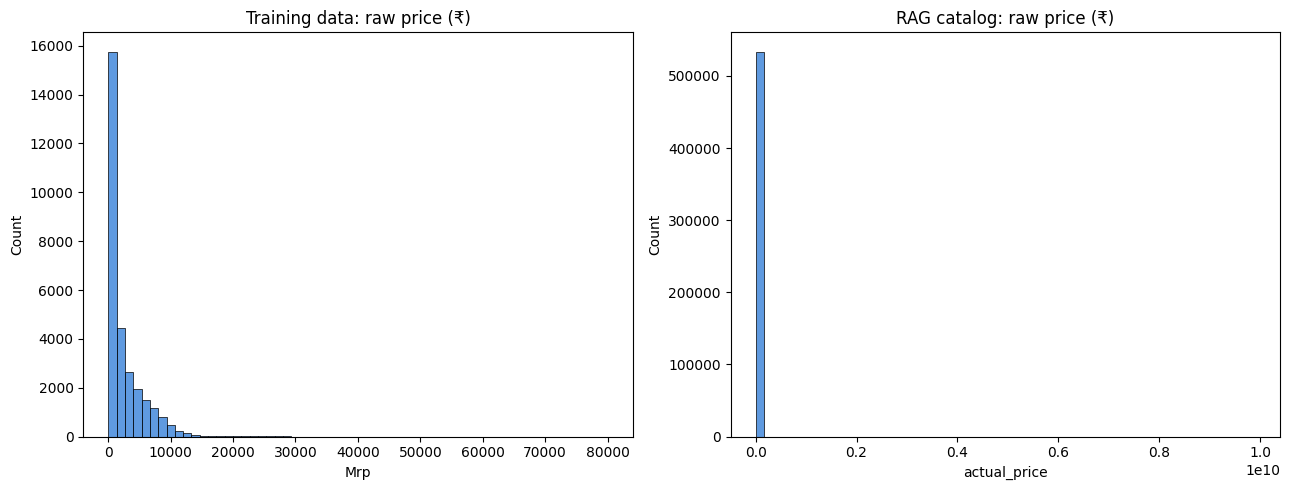

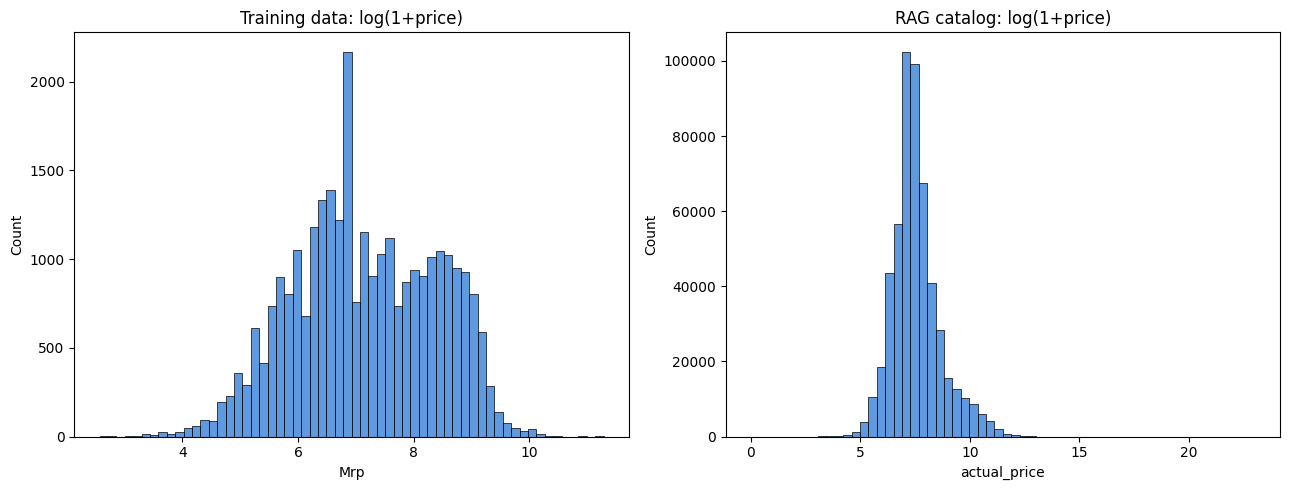

In [3]:
def parse_price(series):
    cleaned = series.astype(str).str.replace(r"[^\d.]", "", regex=True)
    return pd.to_numeric(cleaned, errors="coerce")

# Training data: use Mrp (undiscounted list price) as the "true value" target, not Price
# (the scraped listing's current, possibly-already-discounted price) - same reasoning as
# scripts/clean_training_data.py. Falls back to Price where Mrp is missing.
train_price_col = None
train_prices = None
if df_train is not None:
    train_price_source = df_train["Mrp"].fillna(df_train["Price"]) if "Mrp" in df_train.columns else df_train["Price"]
    train_prices = parse_price(train_price_source).dropna()

rag_price_col = None
rag_prices = None
if df_rag is not None:
    rag_price_col = "actual_price" if "actual_price" in df_rag.columns else ("discount_price" if "discount_price" in df_rag.columns else "price")
    rag_prices = parse_price(df_rag[rag_price_col]).dropna()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
if train_prices is not None:
    sns.histplot(train_prices, bins=60, color=BLUE, ax=axes[0])
    axes[0].set_title("Training data: raw price (₹)")
if rag_prices is not None:
    sns.histplot(rag_prices, bins=60, color=BLUE, ax=axes[1])
    axes[1].set_title("RAG catalog: raw price (₹)")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
if train_prices is not None:
    sns.histplot(np.log1p(train_prices), bins=60, color=BLUE, ax=axes[0])
    axes[0].set_title("Training data: log(1+price)")
if rag_prices is not None:
    sns.histplot(np.log1p(rag_prices), bins=60, color=BLUE, ax=axes[1])
    axes[1].set_title("RAG catalog: log(1+price)")
plt.tight_layout()
plt.show()

## Missing values & duplicates

In [4]:
if df_train is not None:
    print("Training data - missing value rate by column:")
    display((df_train.isna().mean() * 100).round(1).sort_values(ascending=False).to_frame("% missing"))
    dup_key = "Product Asin" if "Product Asin" in df_train.columns else "Product Title"
    dup_rate = df_train.duplicated(subset=[dup_key]).mean() * 100
    print(f"Duplicate rate by {dup_key}: {dup_rate:.1f}%")

if df_rag is not None:
    print("\nRAG catalog - missing value rate by column:")
    display((df_rag.isna().mean() * 100).round(1).sort_values(ascending=False).to_frame("% missing"))
    if {"name", "main_category"}.issubset(df_rag.columns):
        dup_rate = df_rag.duplicated(subset=["name", "main_category"]).mean() * 100
        print(f"Duplicate rate by (name, main_category): {dup_rate:.1f}%")

Training data - missing value rate by column:


,% missing
Combo Offers,99.9
Pack Size Or Quantity,65.9
Product Description,6.6
Mrp,2.3
Price,2.0
Offers,1.6
Brand,0.3
Product Title,0.0
Uniq Id,0.0
Crawl Timestamp,0.0


Duplicate rate by Product Asin: 0.0%

RAG catalog - missing value rate by column:


,% missing
ratings,31.9
no_of_ratings,31.9
discount_price,11.1
actual_price,3.2
name,0.0
Unnamed: 0,0.0
link,0.0
image,0.0
sub_category,0.0
main_category,0.0


Duplicate rate by (name, main_category): 24.9%


## Outlier bound sensitivity

How many rows survive at different `MIN_PRICE`/`MAX_PRICE` candidates? Use this to pick bounds that drop genuine junk (₹0 listings, misprinted ₹1-crore prices) without throwing away real inventory.

In [5]:
CANDIDATE_BOUNDS = [(50, 50000), (100, 100000), (100, 150000), (200, 200000)]

for label, prices in [("Training data", train_prices), ("RAG catalog", rag_prices)]:
    if prices is None:
        continue
    print(f"\n{label} (n={len(prices)}) percentiles:")
    print(prices.quantile([0.01, 0.05, 0.5, 0.95, 0.99]).round(0).to_string())
    print(f"{label} - rows retained at each candidate (min, max):")
    for lo, hi in CANDIDATE_BOUNDS:
        kept = prices[(prices >= lo) & (prices <= hi)]
        print(f"  ({lo:>6}, {hi:>6}): {len(kept):>7} rows kept ({len(kept) / len(prices) * 100:.1f}%)")


Training data (n=29339) percentiles:
0.01       85.0
0.05      179.0
0.50     1170.0
0.95     8640.0
0.99    12621.0
Training data - rows retained at each candidate (min, max):
  (    50,  50000):   29257 rows kept (99.7%)
  (   100, 100000):   28901 rows kept (98.5%)
  (   100, 150000):   28901 rows kept (98.5%)
  (   200, 200000):   27449 rows kept (93.6%)

RAG catalog (n=533772) percentiles:
0.01      200.0
0.05      399.0
0.50     1599.0
0.95    17998.0
0.99    54999.0
RAG catalog - rows retained at each candidate (min, max):
  (    50,  50000):  527228 rows kept (98.8%)
  (   100, 100000):  531706 rows kept (99.6%)
  (   100, 150000):  532398 rows kept (99.7%)
  (   200, 200000):  528561 rows kept (99.0%)


## Category breakdown (RAG catalog)

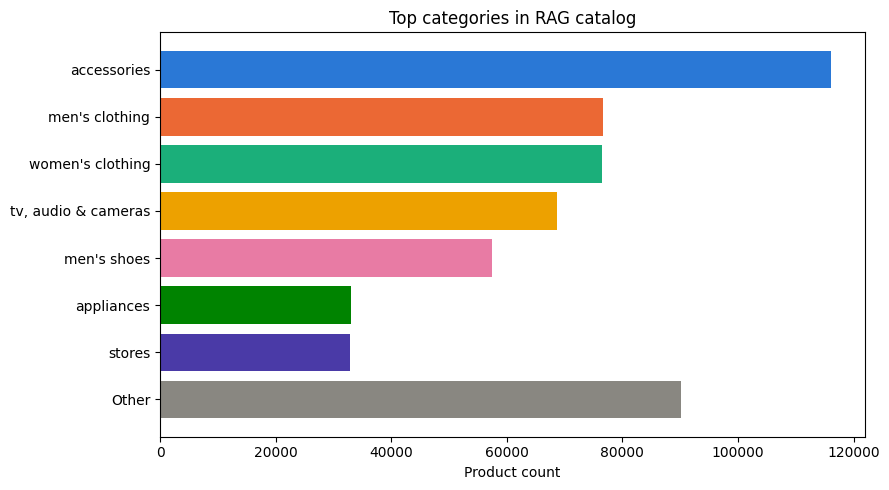

In [6]:
if df_rag is not None and "main_category" in df_rag.columns:
    counts = df_rag["main_category"].value_counts()
    top = counts.head(7)
    other = counts.iloc[7:].sum()
    plot_series = pd.concat([top, pd.Series({"Other": other})]) if other > 0 else top
    colors = CATEGORICAL[: len(top)] + ([MUTED] if other > 0 else [])

    plt.figure(figsize=(9, 5))
    plt.barh(plot_series.index[::-1], plot_series.values[::-1], color=colors[::-1])
    plt.title("Top categories in RAG catalog")
    plt.xlabel("Product count")
    plt.tight_layout()
    plt.show()

## GPU embedding-throughput benchmark

Times a real `SentenceTransformer.encode()` batch on this machine's GPU, then extrapolates how long embedding the full catalog would take - use this to set `MAX_RAG_ITEMS` instead of picking an arbitrary cap.

In [7]:
if df_rag is not None:
    import time
    import torch
    from sentence_transformers import SentenceTransformer

    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"Benchmarking on: {device}")
    model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2", device=device)

    sample_col = "name" if "name" in df_rag.columns else df_rag.columns[0]
    sample_texts = df_rag[sample_col].astype(str).sample(min(2000, len(df_rag)), random_state=42).tolist()

    start = time.time()
    model.encode(sample_texts, batch_size=256, show_progress_bar=False)
    elapsed = time.time() - start
    rate = len(sample_texts) / elapsed
    print(f"Embedded {len(sample_texts)} items in {elapsed:.1f}s -> {rate:.0f} items/sec")

    for n in [50_000, 100_000, 200_000, len(df_rag)]:
        print(f"  Estimated time for {n:>7} items: {n / rate / 60:.1f} min")

c:\Users\yadav\AppData\Local\Programs\Python\Python313\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.4.3)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


Benchmarking on: cuda


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Embedded 2000 items in 2.2s -> 914 items/sec
  Estimated time for   50000 items: 0.9 min
  Estimated time for  100000 items: 1.8 min
  Estimated time for  200000 items: 3.6 min
  Estimated time for  551585 items: 10.1 min


## Deal-threshold sensitivity

Simulates the same "steal deal" discounting `agents/deals.py`'s `ScrapedDeal.fetch_simulated()` uses (treat the catalog price as ground truth, discount a random subset), then checks how many would trigger at different `DEAL_THRESHOLD_PERCENT` / `DEAL_THRESHOLD_ABSOLUTE` combinations - so you can pick a threshold that's neither silent nor noisy.

In [8]:
if train_prices is not None:
    rng = np.random.default_rng(42)
    true_price = train_prices.sample(min(5000, len(train_prices)), random_state=42).to_numpy()
    is_discounted = rng.random(len(true_price)) > 0.7
    discount_factor = np.where(is_discounted, rng.uniform(0.3, 0.6, len(true_price)), rng.uniform(0.9, 1.1, len(true_price)))
    listed_price = true_price * discount_factor

    discount_amount = true_price - listed_price
    discount_percent = discount_amount / true_price

    print(f"Simulated {len(true_price)} listings ({is_discounted.sum()} artificially discounted)\n")
    for pct in [0.20, 0.25, 0.30, 0.35, 0.40]:
        for abs_amt in [300, 500, 1000]:
            hits = ((discount_percent >= pct) | ((discount_amount >= abs_amt) & (listed_price < true_price))).sum()
            print(f"  PERCENT={pct:.2f} ABSOLUTE=₹{abs_amt:>5}: {hits:>4} / {len(true_price)} flagged ({hits / len(true_price) * 100:.1f}%)")

Simulated 5000 listings (1472 artificially discounted)

  PERCENT=0.20 ABSOLUTE=₹  300: 1706 / 5000 flagged (34.1%)
  PERCENT=0.20 ABSOLUTE=₹  500: 1584 / 5000 flagged (31.7%)
  PERCENT=0.20 ABSOLUTE=₹ 1000: 1485 / 5000 flagged (29.7%)
  PERCENT=0.25 ABSOLUTE=₹  300: 1706 / 5000 flagged (34.1%)
  PERCENT=0.25 ABSOLUTE=₹  500: 1584 / 5000 flagged (31.7%)
  PERCENT=0.25 ABSOLUTE=₹ 1000: 1485 / 5000 flagged (29.7%)
  PERCENT=0.30 ABSOLUTE=₹  300: 1706 / 5000 flagged (34.1%)
  PERCENT=0.30 ABSOLUTE=₹  500: 1584 / 5000 flagged (31.7%)
  PERCENT=0.30 ABSOLUTE=₹ 1000: 1485 / 5000 flagged (29.7%)
  PERCENT=0.35 ABSOLUTE=₹  300: 1706 / 5000 flagged (34.1%)
  PERCENT=0.35 ABSOLUTE=₹  500: 1584 / 5000 flagged (31.7%)
  PERCENT=0.35 ABSOLUTE=₹ 1000: 1485 / 5000 flagged (29.7%)
  PERCENT=0.40 ABSOLUTE=₹  300: 1706 / 5000 flagged (34.1%)
  PERCENT=0.40 ABSOLUTE=₹  500: 1584 / 5000 flagged (31.7%)
  PERCENT=0.40 ABSOLUTE=₹ 1000: 1485 / 5000 flagged (29.7%)


## Recommended values

Copy these into `config/settings.py`, then run `scripts/clean_training_data.py` → `clean_rag_data.py` → `prepare_finetune_jsonl.py` → `build_vector_store.py`.

In [9]:
print("Recommended config/settings.py values (adjust if the analysis above suggests otherwise):\n")

if train_prices is not None or rag_prices is not None:
    combined = pd.concat([p for p in [train_prices, rag_prices] if p is not None])
    rec_min = max(50, int(combined.quantile(0.01) // 50 * 50))
    rec_max = int(-(-combined.quantile(0.99) // 1000) * 1000)  # round up to nearest 1000
    print(f"MIN_PRICE = {rec_min}.0")
    print(f"MAX_PRICE = {rec_max}.0")

if df_rag is not None and 'rate' in dir():
    # Aim for roughly a 5-minute local build; fall back to the full catalog if that's fast enough
    budget_seconds = 300
    suggested_n = min(len(df_rag), int(rate * budget_seconds))
    print(f"MAX_RAG_ITEMS = {suggested_n}  # ~{suggested_n / rate / 60:.1f} min to embed on this machine")

print("\nDEAL_THRESHOLD_PERCENT / DEAL_THRESHOLD_ABSOLUTE: pick the combination from the")
print("sensitivity table above whose flagged-rate matches how many alerts you actually want.")

Recommended config/settings.py values (adjust if the analysis above suggests otherwise):

MIN_PRICE = 150.0
MAX_PRICE = 54000.0
MAX_RAG_ITEMS = 274211  # ~5.0 min to embed on this machine

DEAL_THRESHOLD_PERCENT / DEAL_THRESHOLD_ABSOLUTE: pick the combination from the
sensitivity table above whose flagged-rate matches how many alerts you actually want.
